In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 12
Total threads: 96,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38517,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35685,Total threads: 8
Dashboard: http://127.0.0.1:46833/status,Memory: 83.91 GiB
Nanny: tcp://127.0.0.1:43151,


### Load MITgcm Output from Assimilations

In [2]:
foldername = '/home/edavenport/analysis/yannai-waves/energy_flux/'

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [4]:
from xmitgcm import open_mdsdataset
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+31 # jan, feb, mar (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

In [5]:
ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2013-04-01'))

### Compute Density Anomaly

In [6]:
import gsw

In [7]:
p = gsw.p_from_z(ds_tpose_TAO.Z, 0.0) # convert these to pressure at the equator
SA = gsw.SA_from_SP(ds_tpose_TAO.SALT.sel(XC=220,YC=0.0,method='nearest'), p, ds_tpose_TAO.SALT.sel(XC=220,YC=0.0,method='nearest').XC, 0.0)
CT = gsw.CT_from_pt(SA, ds_tpose_TAO.THETA.sel(XC=220,YC=0.0,method='nearest'))
rho = gsw.rho(SA, CT, p)

In [8]:
temp = ds_tpose_TAO.THETA.sel(XC=220,YC=0.0,method='nearest').copy(deep=True)
temp.values = rho
rho = temp

temp = ds_tpose_TAO.THETA.sel(XC=220,YC=0.0,method='nearest').copy(deep=True)
temp.values = SA
SA = temp

temp = ds_tpose_TAO.THETA.sel(XC=220,YC=0.0,method='nearest').copy(deep=True)
temp.values = CT
CT = temp


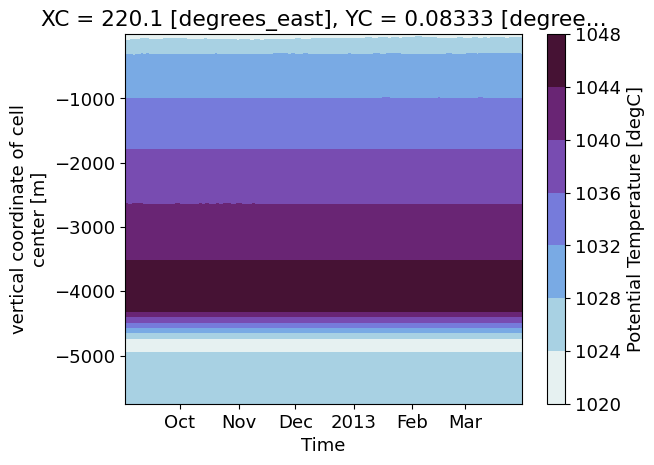

In [9]:
rho.plot.contourf(y='Z',cmap=cmo.dense)

In [10]:
from scipy.signal import butter, sosfiltfilt, detrend
# bandpass density (before reconstructing pressure)

# filtering out high frequency changes
fs = 1/86400 # sampling rate is 1 day (86400 seconds per day)
highF = (1/10)*fs #  
lowF = (1/30)*fs #  
cutoff = np.array([lowF, highF])
order = 4
sos = butter(order, cutoff, 'bandpass', fs=fs, output='sos')

rho_bandpass = sosfiltfilt(sos, detrend(rho,axis=0), axis=0)
uvel_bandpass = sosfiltfilt(sos, detrend(ds_tpose_TAO.UVEL.sel(XG=220,YC=0.0,method='nearest'),axis=0), axis=0)
vvel_bandpass = sosfiltfilt(sos, detrend(ds_tpose_TAO.VVEL.sel(XC=220,YG=0.0,method='nearest'),axis=0), axis=0)
wvel_bandpass = sosfiltfilt(sos, detrend(ds_tpose_TAO.WVEL.sel(XC=220,YC=0.0,method='nearest'),axis=0), axis=0)

In [11]:
temp = rho.copy(deep=True)
temp.data = rho_bandpass
rho_bandpass = temp

temp = ds_tpose_TAO.UVEL.sel(XG=220,YC=0.0,method='nearest').copy(deep=True)
temp.data = uvel_bandpass
uvel_bandpass = temp

temp = ds_tpose_TAO.VVEL.sel(XC=220,YG=0.0,method='nearest').copy(deep=True)
temp.data = vvel_bandpass
vvel_bandpass = temp

temp = ds_tpose_TAO.WVEL.sel(XC=220,YC=0.0,method='nearest').copy(deep=True)
temp.data = wvel_bandpass
wvel_bandpass = temp

rho = rho.where(ds_tpose_TAO.maskC.sel(XC=220,YC=0.0,method='nearest'))
rho_bandpass = rho_bandpass.where(ds_tpose_TAO.maskC.sel(XC=220,YC=0.0,method='nearest'))

In [12]:
g = 9.81

rho_bar = rho_bandpass.mean(dim="time")

rho_prime = rho_bandpass - rho_bar

# multiply by layer thickness
integrand = rho_prime * ds_tpose_TAO.drF

# reverse vertical axis so cumulative sum integrates upward
integrand_rev = integrand.isel(Z=slice(None, None, -1))

# cumulative sum
p_prime_rev = g * integrand_rev.cumsum(dim="Z")

# flip back
p_prime = p_prime_rev.isel(Z=slice(None, None, -1))

In [13]:
p_prime = p_prime - p_prime.isel(Z=0)
temp = ds_tpose_TAO.THETA.sel(XC=220,YC=0.0,method='nearest').copy(deep=True)
temp.values = p_prime
p_prime = temp

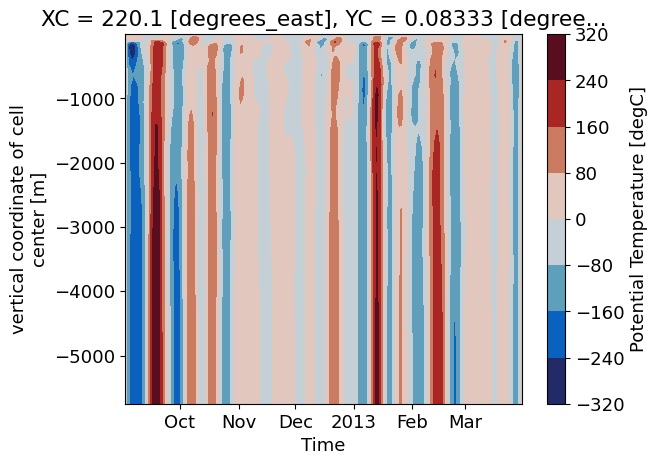

In [14]:
p_prime.plot.contourf(y='Z',cmap=cmo.balance)

In [15]:
# velocity fluctuations
u_prime = uvel_bandpass - uvel_bandpass.mean(dim="time")
v_prime = vvel_bandpass - vvel_bandpass.mean(dim="time")
w_prime = wvel_bandpass - wvel_bandpass.mean(dim="time")

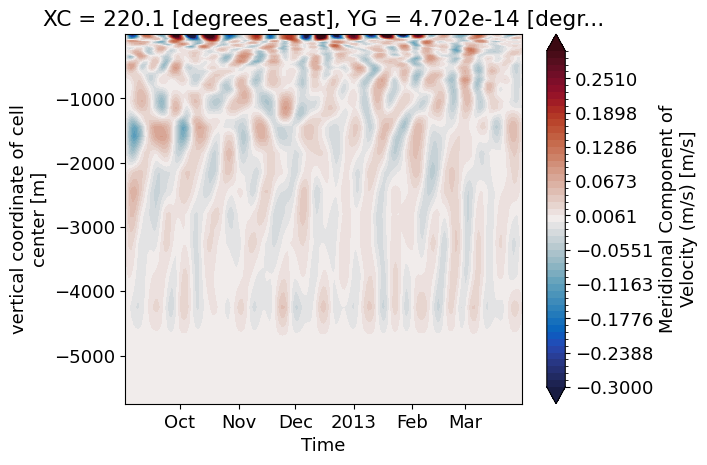

In [16]:
levels = np.linspace(-0.3,0.3,50)
v_prime.plot.contourf(y='Z',cmap=cmo.balance,levels=levels)

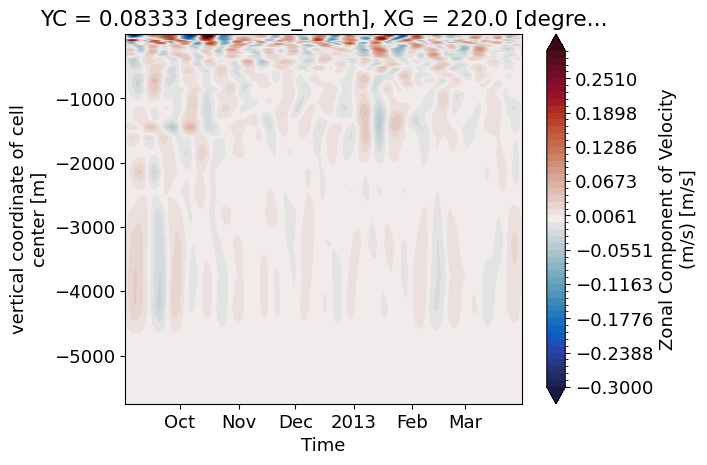

In [17]:
uvel_bandpass.plot.contourf(y='Z',cmap=cmo.balance,levels=levels)

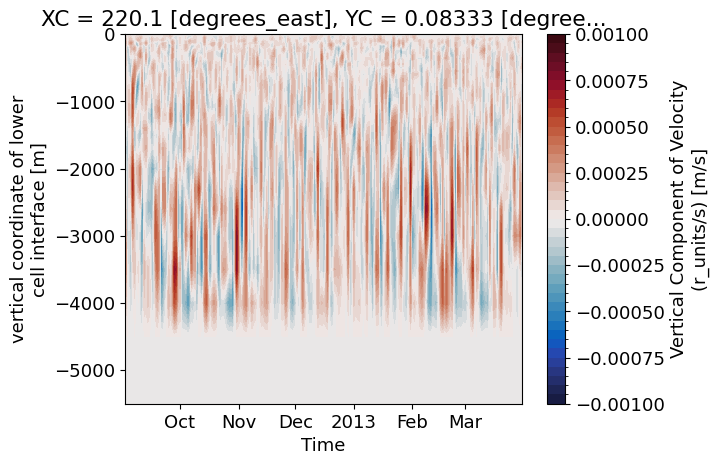

In [18]:
ds_tpose_TAO.WVEL.sel(XC=220,YC=0.0,method='nearest').plot.contourf(y='Zl',cmap=cmo.balance,levels=50)

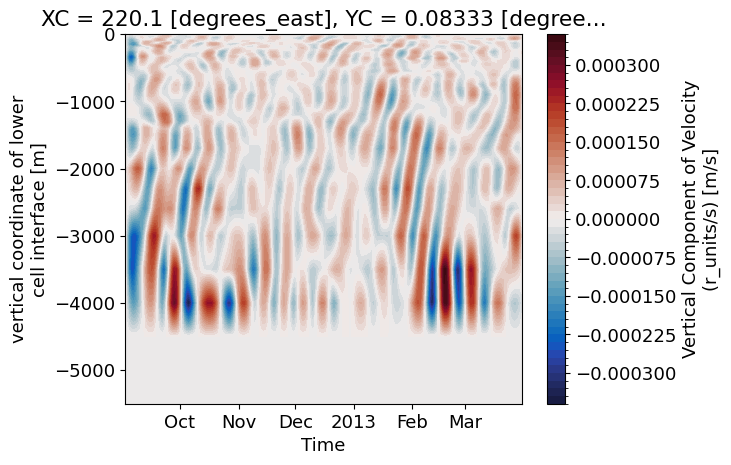

In [19]:
w_prime.plot.contourf(y='Zl',cmap=cmo.balance,levels=50)

In [20]:
import xgcm
grid = xgcm.Grid(ds_tpose_TAO, periodic=['X','Y'])
w_prime_interp = grid.interp(w_prime, 'Z', boundary='fill')
Fx = (p_prime * u_prime).mean(dim="time")
Fy = (p_prime * v_prime).mean(dim="time")
Fz = (p_prime * w_prime_interp).mean(dim="time")

In [21]:
u_rms = np.sqrt((uvel_bandpass**2).mean(dim="time"))

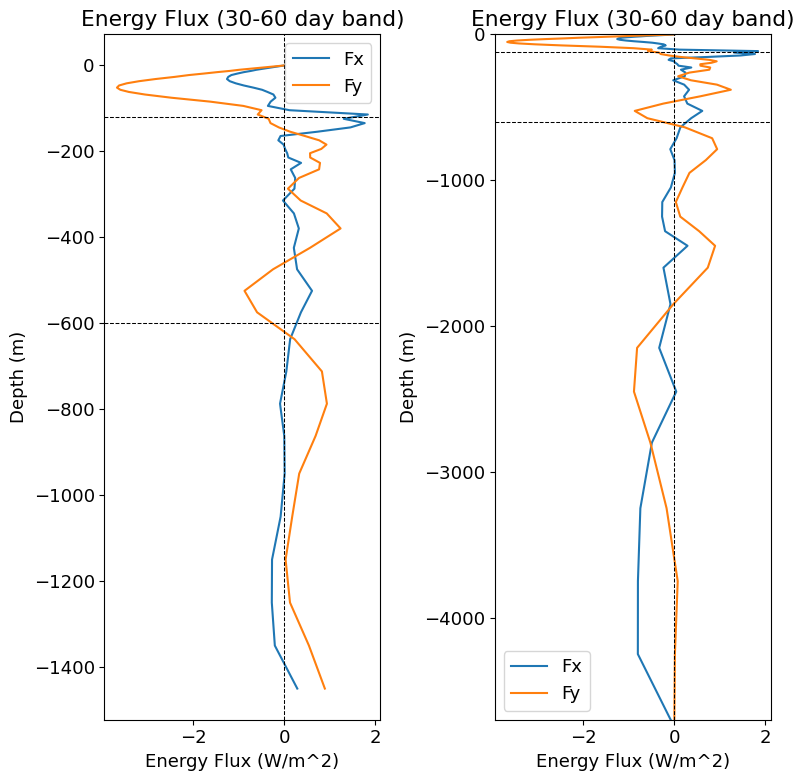

In [22]:
fig, ax = plt.subplots(figsize=(8,8),ncols=2)

Fx.sel(Z=slice(0,-1500)).plot(ax=ax[0],y='Z',label='Fx')
Fy.sel(Z=slice(0,-1500)).plot(ax=ax[0],y='Z',label='Fy')
# Fz.plot(ax=ax,y='Z',label='Fz')
ax[0].legend()
ax[0].set_title('Energy Flux (30-60 day band)')
ax[0].set_xlabel('Energy Flux (W/m^2)')
ax[0].set_ylabel('Depth (m)')
ax[0].axhline(-120,color='k',ls='--',lw=0.75)
ax[0].axhline(-600,color='k',ls='--',lw=0.75)
ax[0].axvline(0,color='k',ls='--',lw=0.75)

Fx.plot(ax=ax[1],y='Z',label='Fx')
Fy.plot(ax=ax[1],y='Z',label='Fy')
# Fz.plot(ax=ax,y='Z',label='Fz')
ax[1].legend()
ax[1].set_title('Energy Flux (30-60 day band)')
ax[1].set_xlabel('Energy Flux (W/m^2)')
ax[1].set_ylabel('Depth (m)')
ax[1].axhline(-120,color='k',ls='--',lw=0.75)
ax[1].axhline(-600,color='k',ls='--',lw=0.75)
ax[1].axvline(0,color='k',ls='--',lw=0.75)
ax[1].set_ylim(-4700,0)
plt.tight_layout()
fig.savefig(foldername + 'energy_flux_profiles_highfreq.png',dpi=300)

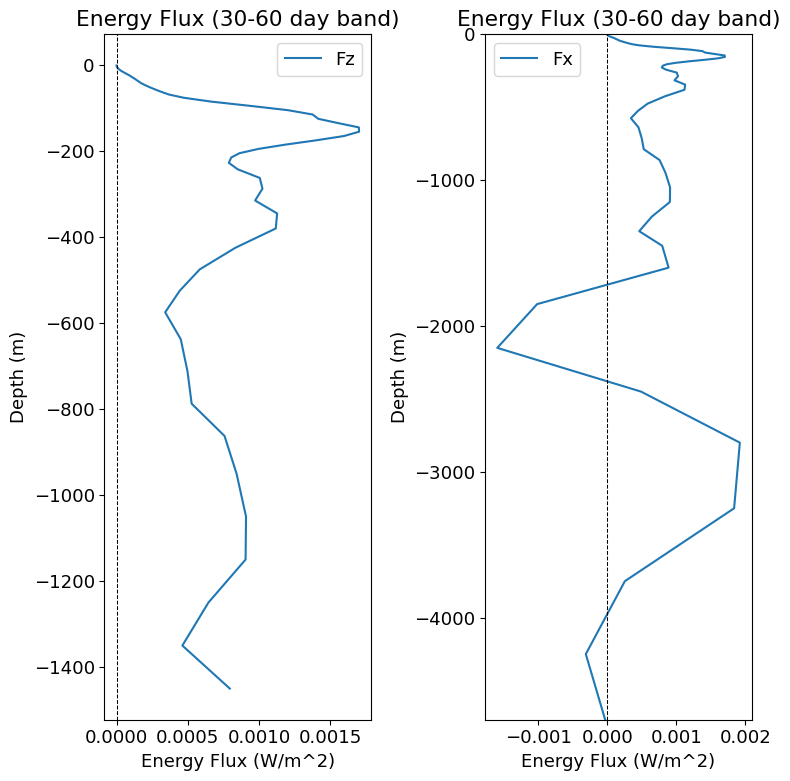

In [23]:
fig, ax = plt.subplots(figsize=(8,8),ncols=2)

Fz.sel(Z=slice(0,-1500)).plot(ax=ax[0],y='Z',label='Fz')
ax[0].legend()
ax[0].set_title('Energy Flux (30-60 day band)')
ax[0].set_xlabel('Energy Flux (W/m^2)')
ax[0].set_ylabel('Depth (m)')
# ax[0].axhline(-120,color='k',ls='--',lw=0.75)
# ax[0].axhline(-600,color='k',ls='--',lw=0.75)
ax[0].axvline(0,color='k',ls='--',lw=0.75)

Fz.plot(ax=ax[1],y='Z',label='Fx')
ax[1].legend()
ax[1].set_title('Energy Flux (30-60 day band)')
ax[1].set_xlabel('Energy Flux (W/m^2)')
ax[1].set_ylabel('Depth (m)')
# ax[1].axhline(-120,color='k',ls='--',lw=0.75)
# ax[1].axhline(-600,color='k',ls='--',lw=0.75)
ax[1].axvline(0,color='k',ls='--',lw=0.75)
ax[1].set_ylim(-4700,0)
plt.tight_layout()
fig.savefig(foldername + 'Fz_profiles_highfreq.png',dpi=300)

### Repeat without TAO assimilation

In [24]:
p = gsw.p_from_z(ds_tpose_noTAO.Z, 0.0) # convert these to pressure at the equator
SA = gsw.SA_from_SP(ds_tpose_noTAO.SALT.sel(XC=220,YC=0.0,method='nearest'), p, ds_tpose_noTAO.SALT.sel(XC=220,YC=0.0,method='nearest').XC, 0.0)
CT = gsw.CT_from_pt(SA, ds_tpose_noTAO.THETA.sel(XC=220,YC=0.0,method='nearest'))
rho = gsw.rho(SA, CT, p)

temp = ds_tpose_noTAO.THETA.sel(XC=220,YC=0.0,method='nearest').copy(deep=True)
temp.values = rho
rho = temp

temp = ds_tpose_noTAO.THETA.sel(XC=220,YC=0.0,method='nearest').copy(deep=True)
temp.values = SA
SA = temp

temp = ds_tpose_noTAO.THETA.sel(XC=220,YC=0.0,method='nearest').copy(deep=True)
temp.values = CT
CT = temp

rho_bandpass = sosfiltfilt(sos, detrend(rho,axis=0), axis=0)
uvel_bandpass = sosfiltfilt(sos, detrend(ds_tpose_noTAO.UVEL.sel(XG=220,YC=0.0,method='nearest'),axis=0), axis=0)
vvel_bandpass = sosfiltfilt(sos, detrend(ds_tpose_noTAO.VVEL.sel(XC=220,YG=0.0,method='nearest'),axis=0), axis=0)
wvel_bandpass = sosfiltfilt(sos, detrend(ds_tpose_noTAO.WVEL.sel(XC=220,YC=0.0,method='nearest'),axis=0), axis=0)

temp = rho.copy(deep=True)
temp.data = rho_bandpass
rho_bandpass = temp

temp = ds_tpose_noTAO.UVEL.sel(XG=220,YC=0.0,method='nearest').copy(deep=True)
temp.data = uvel_bandpass
uvel_bandpass = temp

temp = ds_tpose_noTAO.VVEL.sel(XC=220,YG=0.0,method='nearest').copy(deep=True)
temp.data = vvel_bandpass
vvel_bandpass = temp

temp = ds_tpose_noTAO.WVEL.sel(XC=220,YC=0.0,method='nearest').copy(deep=True)
temp.data = wvel_bandpass
wvel_bandpass = temp

rho = rho.where(ds_tpose_noTAO.maskC.sel(XC=220,YC=0.0,method='nearest'))
rho_bandpass = rho_bandpass.where(ds_tpose_noTAO.maskC.sel(XC=220,YC=0.0,method='nearest'))

In [25]:
rho_bar = rho_bandpass.mean(dim="time")

rho_prime = rho_bandpass - rho_bar

# multiply by layer thickness
integrand = rho_prime * ds_tpose_noTAO.drF

# reverse vertical axis so cumulative sum integrates upward
integrand_rev = integrand.isel(Z=slice(None, None, -1))

# cumulative sum
p_prime_rev = g * integrand_rev.cumsum(dim="Z")

# flip back
p_prime = p_prime_rev.isel(Z=slice(None, None, -1))

In [26]:
p_prime = p_prime - p_prime.isel(Z=0)
temp = ds_tpose_noTAO.THETA.sel(XC=220,YC=0.0,method='nearest').copy(deep=True)
temp.values = p_prime
p_prime = temp

In [27]:
u_prime = uvel_bandpass - uvel_bandpass.mean(dim="time")
v_prime = vvel_bandpass - vvel_bandpass.mean(dim="time")
w_prime = wvel_bandpass - wvel_bandpass.mean(dim="time")

In [28]:
grid = xgcm.Grid(ds_tpose_noTAO, periodic=['X','Y'])
w_prime_interp = grid.interp(w_prime, 'Z', boundary='fill')
Fx_noTAO = (p_prime * u_prime).mean(dim="time")
Fy_noTAO = (p_prime * v_prime).mean(dim="time")
Fz_noTAO = (p_prime * w_prime_interp).mean(dim="time")

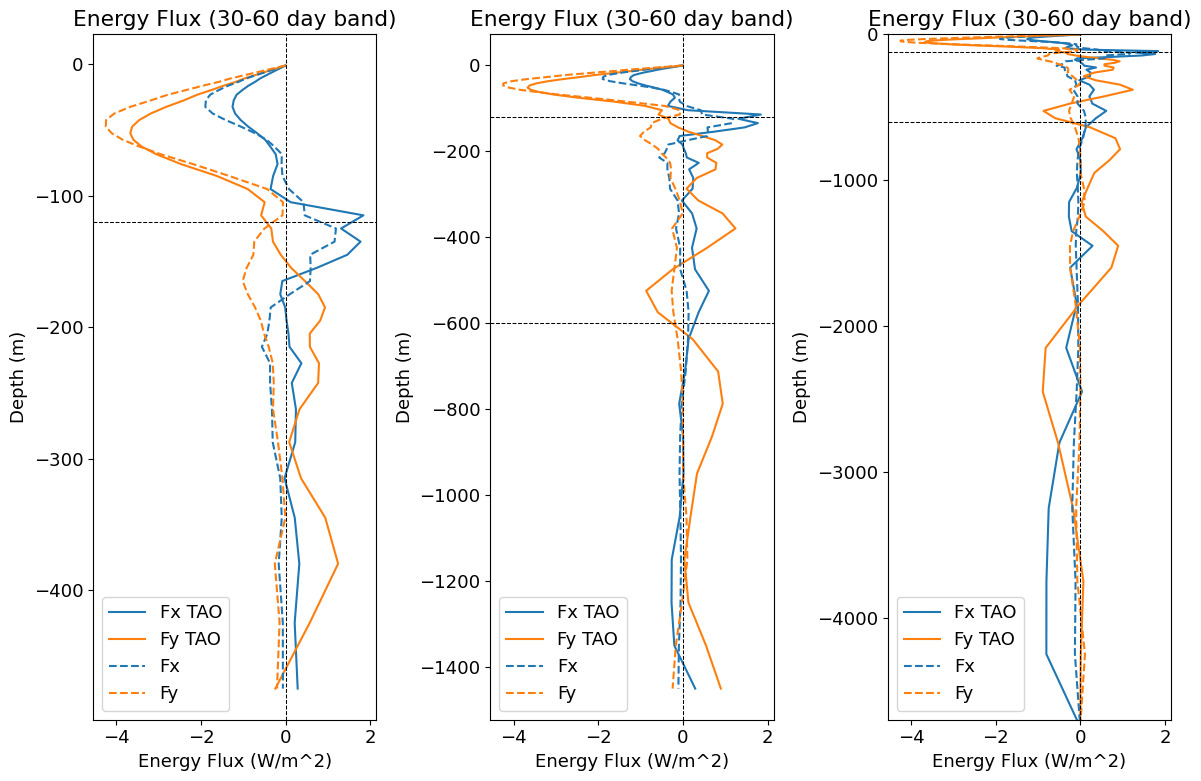

In [29]:
fig, ax = plt.subplots(figsize=(12,8),ncols=3)

Fx.sel(Z=slice(0,-500)).plot(ax=ax[0],y='Z',label='Fx TAO',color='tab:blue')
Fy.sel(Z=slice(0,-500)).plot(ax=ax[0],y='Z',label='Fy TAO',color='tab:orange')
Fx_noTAO.sel(Z=slice(0,-500)).plot(ax=ax[0],y='Z',label='Fx',ls='--',color='tab:blue')
Fy_noTAO.sel(Z=slice(0,-500)).plot(ax=ax[0],y='Z',label='Fy',ls='--',color='tab:orange')
ax[0].legend()
ax[0].set_title('Energy Flux (30-60 day band)')
ax[0].set_xlabel('Energy Flux (W/m^2)')
ax[0].set_ylabel('Depth (m)')
ax[0].axhline(-120,color='k',ls='--',lw=0.75)
ax[0].axvline(0,color='k',ls='--',lw=0.75)

Fx.sel(Z=slice(0,-1500)).plot(ax=ax[1],y='Z',label='Fx TAO',color='tab:blue')
Fy.sel(Z=slice(0,-1500)).plot(ax=ax[1],y='Z',label='Fy TAO',color='tab:orange')
Fx_noTAO.sel(Z=slice(0,-1500)).plot(ax=ax[1],y='Z',label='Fx',ls='--',color='tab:blue')
Fy_noTAO.sel(Z=slice(0,-1500)).plot(ax=ax[1],y='Z',label='Fy',ls='--',color='tab:orange')
ax[1].legend()
ax[1].set_title('Energy Flux (30-60 day band)')
ax[1].set_xlabel('Energy Flux (W/m^2)')
ax[1].set_ylabel('Depth (m)')
ax[1].axhline(-120,color='k',ls='--',lw=0.75)
ax[1].axhline(-600,color='k',ls='--',lw=0.75)
ax[1].axvline(0,color='k',ls='--',lw=0.75)

Fx.plot(ax=ax[2],y='Z',label='Fx TAO',color='tab:blue')
Fy.plot(ax=ax[2],y='Z',label='Fy TAO',color='tab:orange')
Fx_noTAO.plot(ax=ax[2],y='Z',label='Fx',ls='--',color='tab:blue')
Fy_noTAO.plot(ax=ax[2],y='Z',label='Fy',ls='--',color='tab:orange')
ax[2].legend()
ax[2].set_title('Energy Flux (30-60 day band)')
ax[2].set_xlabel('Energy Flux (W/m^2)')
ax[2].set_ylabel('Depth (m)')
ax[2].axhline(-120,color='k',ls='--',lw=0.75)
ax[2].axhline(-600,color='k',ls='--',lw=0.75)
ax[2].axvline(0,color='k',ls='--',lw=0.75)
ax[2].set_ylim(-4700,0)
plt.tight_layout()
fig.savefig(foldername + 'energy_flux_profiles_compare_highfreq.png',dpi=300)

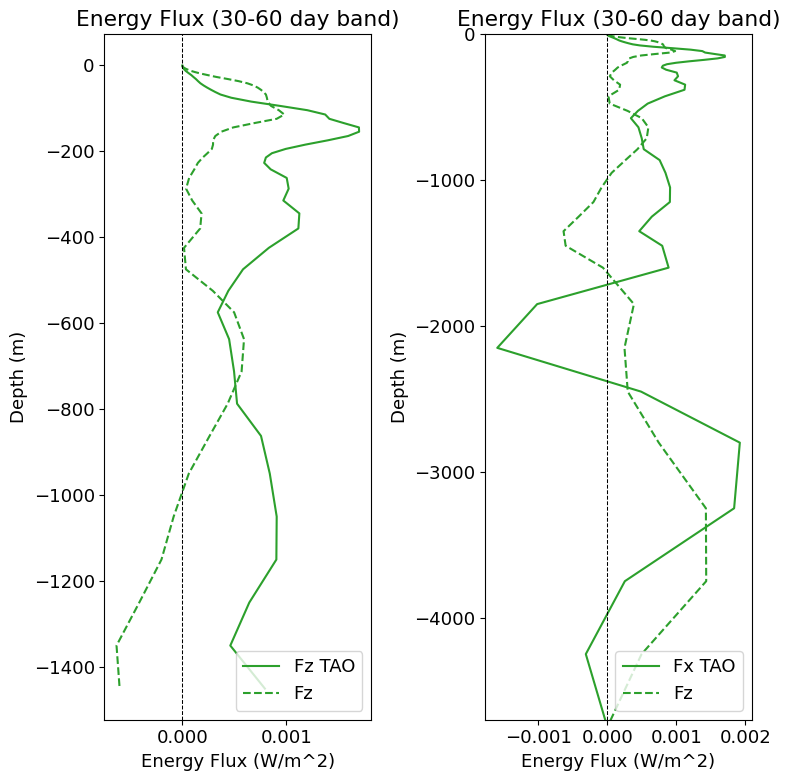

In [30]:
fig, ax = plt.subplots(figsize=(8,8),ncols=2)

Fz.sel(Z=slice(0,-1500)).plot(ax=ax[0],y='Z',label='Fz TAO',color='tab:green')
Fz_noTAO.sel(Z=slice(0,-1500)).plot(ax=ax[0],y='Z',label='Fz',ls='--',color='tab:green')
ax[0].legend()
ax[0].set_title('Energy Flux (30-60 day band)')
ax[0].set_xlabel('Energy Flux (W/m^2)')
ax[0].set_ylabel('Depth (m)')
# ax[0].axhline(-120,color='k',ls='--',lw=0.75)
# ax[0].axhline(-600,color='k',ls='--',lw=0.75)
ax[0].axvline(0,color='k',ls='--',lw=0.75)

Fz.plot(ax=ax[1],y='Z',label='Fx TAO',color='tab:green')
Fz_noTAO.plot(ax=ax[1],y='Z',label='Fz',ls='--',color='tab:green')
ax[1].legend()
ax[1].set_title('Energy Flux (30-60 day band)')
ax[1].set_xlabel('Energy Flux (W/m^2)')
ax[1].set_ylabel('Depth (m)')
# ax[1].axhline(-120,color='k',ls='--',lw=0.75)
# ax[1].axhline(-600,color='k',ls='--',lw=0.75)
ax[1].axvline(0,color='k',ls='--',lw=0.75)
ax[1].set_ylim(-4700,0)
plt.tight_layout()
fig.savefig(foldername + 'Fz_profiles_compare_highfreq.png',dpi=300)

In [31]:
client.shutdown()
cluster.close()
client.close()